<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/Gy25-Fysik-Matte-AI-Labbar-Danderyds-Gymnasium-/blob/main/ML_LABB1_Hur_exakt_ar_pi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-LABB 1 — Hur exakt är π?
### Fysik 1 · Mätning, osäkerhet och din första modell

---

**Namn:** _______________________  **Grupp:** _______  **Datum:** _______

---

## Vad ska vi göra?

Ni har mätt diametern *d* och omkretsen *C* på ett antal runda föremål.
Ni vet att sambandet är

$$C = \pi \cdot d$$

Men låtsas nu att ni **inte** vet vad π är. Frågan blir:

> **Kan vi hitta π enbart utifrån våra egna mätningar?**

Svaret är ja — och sättet vi gör det på är exakt så maskininlärning fungerar.

## Så kör du en cell

Klicka i cellen och tryck **Shift + Enter**. Kör cellerna **uppifrån och ned**, en i taget.
Du behöver inte kunna programmera — du ska bara ändra siffror där det står `ÄNDRA HÄR`.


---
## Del 1 · Skriv in era mätdata


Fyll i era egna mätvärden nedan. Skriv **samma antal värden** i båda listorna,
och håll ordningen (första diametern hör ihop med första omkretsen).

Alla längder i **centimeter**. Använd punkt som decimaltecken: `7.6` — inte `7,6`.

> Exempelvärdena som redan står där är riktiga mätningar. Kör gärna cellen en gång
> som den är för att se att allt fungerar — byt sedan ut mot era egna.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===== ÄNDRA HÄR: era egna mätvärden =====
namn = ['1-krona', 'Tejprulle', 'Konservburk', 'Kaffekopp',
        'CD-skiva', 'Tallrik', 'Hink', 'Papperskorg']

d = np.array([ 2.5,  7.6,  7.4,  8.2, 12.0, 21.5, 26.0, 30.5])   # diameter (cm)
C = np.array([ 7.9, 24.1, 23.0, 25.6, 37.5, 67.9, 81.2, 96.4])   # omkrets  (cm)
# ==========================================

# Kontroll: lika många värden i listorna?
if len(d) != len(C):
    print('FEL: du har', len(d), 'diametrar men', len(C), 'omkretsar. De måste vara lika många.')
else:
    print('Bra! Ni har', len(d), 'mätpunkter.')
    print()
    print(f"{'Föremål':<14}{'d (cm)':>9}{'C (cm)':>9}")
    for i in range(len(d)):
        etikett = namn[i] if i < len(namn) else f'Föremål {i+1}'
        print(f'{etikett:<14}{d[i]:>9.1f}{C[i]:>9.1f}')


Bra! Ni har 8 mätpunkter.

Föremål          d (cm)   C (cm)
1-krona             2.5      7.9
Tejprulle           7.6     24.1
Konservburk         7.4     23.0
Kaffekopp           8.2     25.6
CD-skiva           12.0     37.5
Tallrik            21.5     67.9
Hink               26.0     81.2
Papperskorg        30.5     96.4


---
## Del 2 · Titta på era data först


Innan man räknar ska man alltid **titta**. Varje punkt är ett föremål ni mätt.

**Fråga:** ligger punkterna ungefär på en rät linje genom origo? Varför just genom origo?


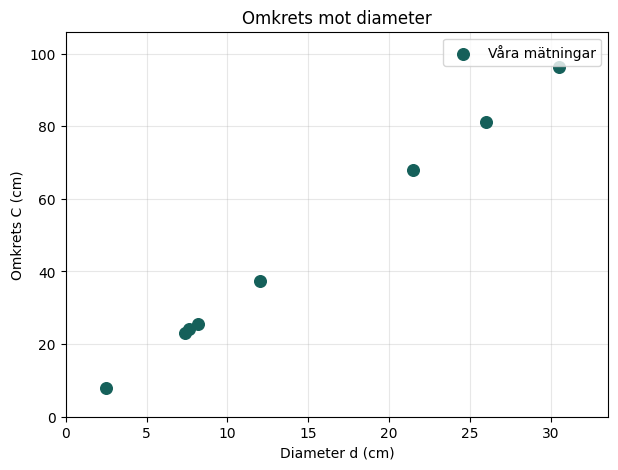

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(d, C, s=70, color='#15605A', zorder=3, label='Våra mätningar')
plt.xlabel('Diameter d (cm)')
plt.ylabel('Omkrets C (cm)')
plt.title('Omkrets mot diameter')
plt.grid(alpha=0.3)
plt.xlim(0, max(d)*1.1)
plt.ylim(0, max(C)*1.1)
plt.legend()
plt.show()


---
## Del 3 · Gissa själv — och mät hur fel du har


Vår **modell** är den enkla formeln

$$C = k \cdot d$$

där *k* är ett tal vi ska hitta. Gissa ett värde på *k* nedan och kör cellen.

För att veta hur bra gissningen är räknar vi ut ett **fel** för varje mätpunkt:
skillnaden mellan det vi *mätte* och det modellen *förutsäger*. Sedan kvadrerar vi
varje fel (så att plus och minus inte tar ut varandra) och lägger ihop allt:

$$L(k) = \sum_i \left( C_i - k \cdot d_i \right)^2$$

Det talet kallas **felsumman** — på engelska *loss*. **Ju mindre, desto bättre modell.**

> Prova några olika värden: 2.5, 3.0, 3.2, 3.5. Hur litet kan du få felsumman?


Din gissning:  k = 3.0
Felsumma L(k) = 51.55

Föremål         Uppmätt C   Modellen      Fel
1-krona               7.9        7.5    +0.40
Tejprulle            24.1       22.8    +1.30
Konservburk          23.0       22.2    +0.80
Kaffekopp            25.6       24.6    +1.00
CD-skiva             37.5       36.0    +1.50
Tallrik              67.9       64.5    +3.40
Hink                 81.2       78.0    +3.20
Papperskorg          96.4       91.5    +4.90


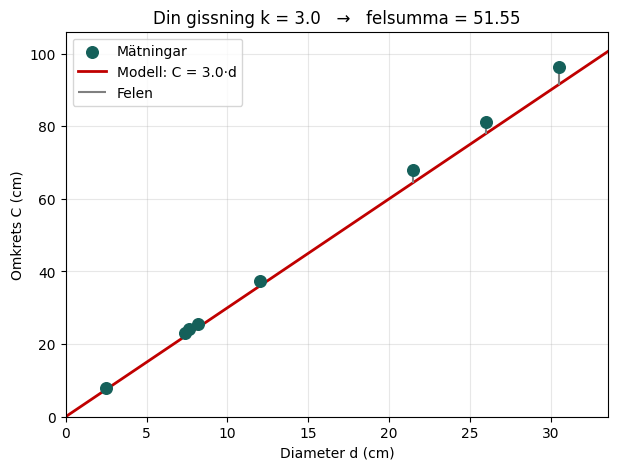

In [3]:
# ===== ÄNDRA HÄR: din gissning =====
mitt_k = 3.0
# ===================================

forutsagt = mitt_k * d          # vad modellen tror att omkretsen är
fel = C - forutsagt             # hur fel modellen har, per föremål
felsumma = np.sum(fel**2)       # loss

print(f'Din gissning:  k = {mitt_k}')
print(f'Felsumma L(k) = {felsumma:.2f}')
print()
print(f"{'Föremål':<14}{'Uppmätt C':>11}{'Modellen':>11}{'Fel':>9}")
for i in range(len(d)):
    etikett = namn[i] if i < len(namn) else f'Föremål {i+1}'
    print(f'{etikett:<14}{C[i]:>11.1f}{forutsagt[i]:>11.1f}{fel[i]:>+9.2f}')

# Rita mätpunkterna och din linje
x = np.linspace(0, max(d)*1.1, 100)
plt.figure(figsize=(7, 5))
plt.scatter(d, C, s=70, color='#15605A', zorder=3, label='Mätningar')
plt.plot(x, mitt_k*x, color='#C00000', lw=2, label=f'Modell: C = {mitt_k}·d')
plt.vlines(d, forutsagt, C, color='gray', lw=1.5, zorder=2, label='Felen')
plt.xlabel('Diameter d (cm)'); plt.ylabel('Omkrets C (cm)')
plt.title(f'Din gissning k = {mitt_k}   →   felsumma = {felsumma:.2f}')
plt.grid(alpha=0.3); plt.legend(); plt.xlim(0, max(d)*1.1); plt.ylim(0, max(C)*1.1)
plt.show()


---
## Del 4 · Låt datorn testa alla värden på k


Att gissa för hand går långsamt. Låt i stället datorn testa **1300 olika värden** på *k*
och rita upp felsumman för varje. Då ser vi hela landskapet på en gång.


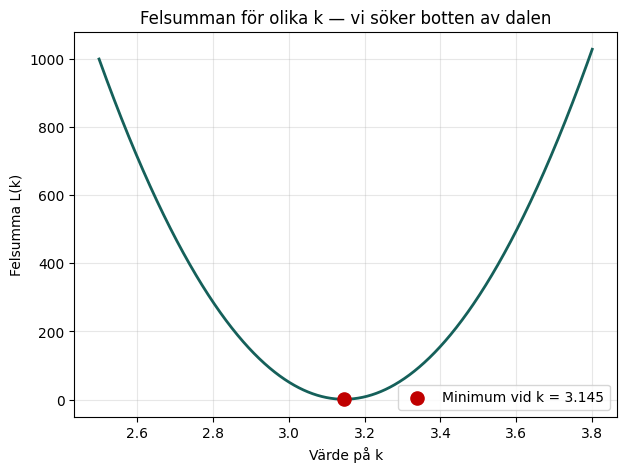

Bästa k enligt datorn: 3.145


In [4]:
k_test = np.linspace(2.5, 3.8, 1301)
L = np.array([np.sum((C - k*d)**2) for k in k_test])

k_bast = k_test[np.argmin(L)]      # det k som gav minst felsumma

plt.figure(figsize=(7, 5))
plt.plot(k_test, L, color='#15605A', lw=2)
plt.scatter([k_bast], [L.min()], color='#C00000', s=90, zorder=3,
            label=f'Minimum vid k = {k_bast:.3f}')
plt.xlabel('Värde på k'); plt.ylabel('Felsumma L(k)')
plt.title('Felsumman för olika k — vi söker botten av dalen')
plt.grid(alpha=0.3); plt.legend()
plt.show()

print(f'Bästa k enligt datorn: {k_bast:.3f}')


> **Stanna upp här.** Kurvan ni just ritade är en *dal*. Botten av dalen är det bästa värdet på *k*.
>
> Det är hela idén bakom maskininlärning: skriv en modell, mät hur fel den har,
> och leta upp botten av dalen. Skillnaden mot ett riktigt AI-system är bara att det
> har miljontals parametrar i stället för en enda — så dalen går inte att rita.


---
## Del 5 · Den exakta lösningen


För vår enkla modell behöver vi faktiskt inte leta alls. Matematiken ger ett exakt svar:

$$k = \frac{\sum_i d_i C_i}{\sum_i d_i^{\,2}}$$

Det är precis vad **minsta kvadratmetoden** gör. Jämför med datorns sökning ovan.


In [5]:
k_exakt = np.sum(d * C) / np.sum(d**2)

print(f'Sökning i Del 4 : k = {k_bast:.4f}')
print(f'Exakt formel    : k = {k_exakt:.4f}')
print()
print('Vår modell:  C = %.4f · d' % k_exakt)


Sökning i Del 4 : k = 3.1450
Exakt formel    : k = 3.1454

Vår modell:  C = 3.1454 · d


---
## Del 6 · Noggrannhet — hur nära sanningen kom vi?


Nu avslöjar vi facit. Det sanna värdet är π = 3,14159…

**Noggrannhet** anger hur nära vårt värde ligger det sanna värdet.


Vårt värde   k = 3.1454
Sanna värdet π = 3.1416
Avvikelse      = +0.0038   (+0.12 %)


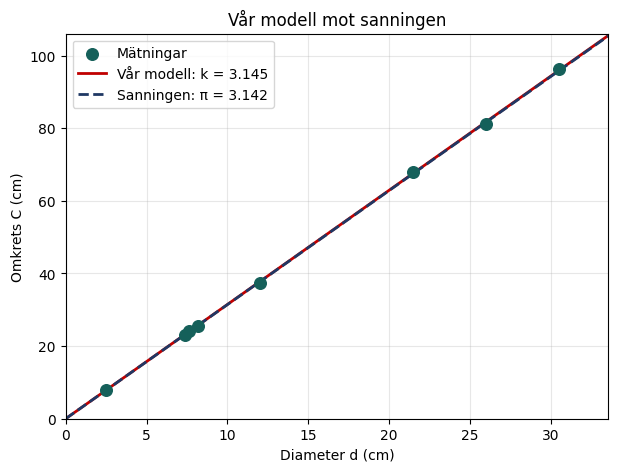

In [6]:
pi_sant = np.pi
avvikelse = k_exakt - pi_sant
procent = 100 * avvikelse / pi_sant

print(f'Vårt värde   k = {k_exakt:.4f}')
print(f'Sanna värdet π = {pi_sant:.4f}')
print(f'Avvikelse      = {avvikelse:+.4f}   ({procent:+.2f} %)')

x = np.linspace(0, max(d)*1.1, 100)
plt.figure(figsize=(7, 5))
plt.scatter(d, C, s=70, color='#15605A', zorder=3, label='Mätningar')
plt.plot(x, k_exakt*x, color='#C00000', lw=2, label=f'Vår modell: k = {k_exakt:.3f}')
plt.plot(x, pi_sant*x, color='#1F3864', lw=2, ls='--', label=f'Sanningen: π = {pi_sant:.3f}')
plt.xlabel('Diameter d (cm)'); plt.ylabel('Omkrets C (cm)')
plt.title('Vår modell mot sanningen')
plt.grid(alpha=0.3); plt.legend(); plt.xlim(0, max(d)*1.1); plt.ylim(0, max(C)*1.1)
plt.show()


---
## Del 7 · Mätosäkerhet — hur säkra är vi på vårt k?


Det som blir kvar när modellen dragits bort kallas **residualer** — mätpunkten minus modellen.
De visar hur mycket brus som finns i era mätningar.

Ur residualernas storlek kan vi räkna ut hur osäkert vårt *k* är, och skriva svaret
på den form ni är vana vid: **k ± osäkerhet**.

**Titta på residualdiagrammet:** ligger punkterna slumpmässigt spridda kring noll?
Då är det bara slumpmässiga mätfel. Syns i stället ett *mönster* — till exempel att alla
stora föremål ligger under noll — betyder det att något systematiskt är fel.


Residualer (cm): [ 0.04  0.19 -0.28 -0.19 -0.24  0.27 -0.58  0.47]
Typisk avvikelse per mätning: 0.35 cm

RESULTAT:  k = 3.145 ± 0.007
Intervall: 3.1383  till  3.1525

π ligger INOM vår osäkerhet — mätningen är förenlig med det sanna värdet.


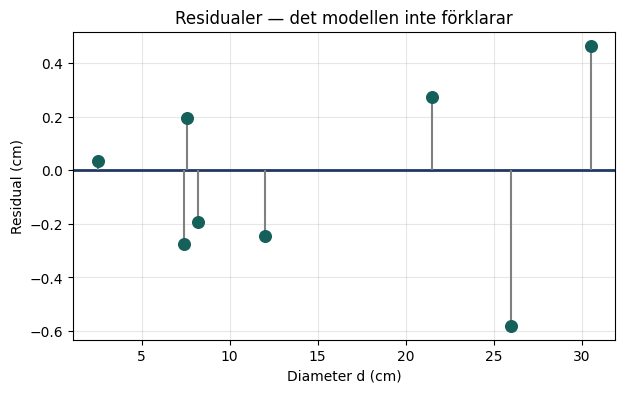

In [7]:
residual = C - k_exakt * d
n = len(d)

s  = np.sqrt(np.sum(residual**2) / (n - 1))     # typisk storlek på ett mätfel
sk = s / np.sqrt(np.sum(d**2))                  # osäkerhet i vårt k

print('Residualer (cm):', np.round(residual, 2))
print(f'Typisk avvikelse per mätning: {s:.2f} cm')
print()

# Avrunda som ni lärt er: osäkerheten till EN värdesiffra,
# och k till samma decimal som osäkerheten.
import math
platser = -math.floor(math.log10(sk))
sk_avr = round(sk, platser)
k_avr  = round(k_exakt, platser)

print(f'RESULTAT:  k = {k_avr} ± {sk_avr}')
print(f'Intervall: {k_exakt-sk:.4f}  till  {k_exakt+sk:.4f}')
print()
if abs(k_exakt - np.pi) < sk:
    print('π ligger INOM vår osäkerhet — mätningen är förenlig med det sanna värdet.')
else:
    print('π ligger UTANFÖR vår osäkerhet — leta efter ett systematiskt fel!')

plt.figure(figsize=(7, 4))
plt.axhline(0, color='#1F3864', lw=2)
plt.scatter(d, residual, s=70, color='#15605A', zorder=3)
plt.vlines(d, 0, residual, color='gray', lw=1.5)
plt.xlabel('Diameter d (cm)'); plt.ylabel('Residual (cm)')
plt.title('Residualer — det modellen inte förklarar')
plt.grid(alpha=0.3)
plt.show()


---
## Del 8 · Precision — jämför med resten av klassen


**Noggrannhet** var hur nära π *er* grupp kom.
**Precision** är hur nära varandra *alla gruppers* svar ligger.

Samla in alla gruppers k-värden och skriv in dem nedan.


Klassens medelvärde : 3.1375
Spridning           : 0.0316   ← detta är PRECISIONEN
Sanna värdet π      : 3.1416
Medelvärdets fel    : -0.0041   ← detta är NOGGRANNHETEN


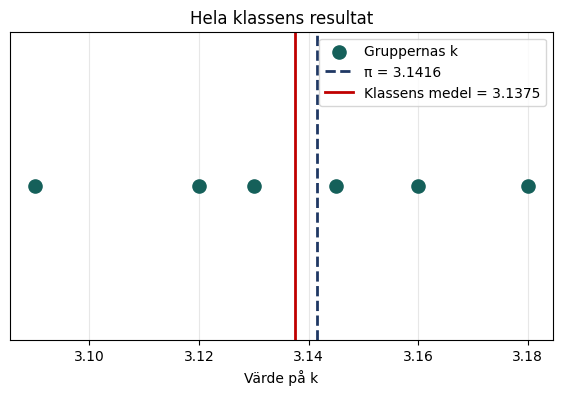

In [8]:
# ===== ÄNDRA HÄR: alla gruppers k-värden =====
klassens_k = [3.145, 3.09, 3.18, 3.12, 3.16, 3.13]
# =============================================

klassens_k = np.array(klassens_k)
medel = klassens_k.mean()
spridning = klassens_k.std(ddof=1)

print(f'Klassens medelvärde : {medel:.4f}')
print(f'Spridning           : {spridning:.4f}   ← detta är PRECISIONEN')
print(f'Sanna värdet π      : {np.pi:.4f}')
print(f'Medelvärdets fel    : {medel - np.pi:+.4f}   ← detta är NOGGRANNHETEN')

plt.figure(figsize=(7, 4))
plt.scatter(klassens_k, np.zeros_like(klassens_k), s=90, color='#15605A',
            zorder=3, label='Gruppernas k')
plt.axvline(np.pi, color='#1F3864', lw=2, ls='--', label=f'π = {np.pi:.4f}')
plt.axvline(medel, color='#C00000', lw=2, label=f'Klassens medel = {medel:.4f}')
plt.yticks([])
plt.xlabel('Värde på k')
plt.title('Hela klassens resultat')
plt.grid(alpha=0.3, axis='x'); plt.legend()
plt.show()


---
## Del 9 · Frågor att svara på i rapporten

Svara med hela meningar direkt i den här cellen (dubbelklicka för att skriva).

**1.** Vad betyder felsumman *L(k)*, med egna ord? Varför kvadrerar vi felen i stället för att bara addera dem?

*Svar:*

**2.** Er graf i Del 4 var en dal. Vad betyder botten av dalen rent fysikaliskt?

*Svar:*

**3.** Vilket värde fick ni på *k*, och hur nära π kom ni? Ange svaret som k ± osäkerhet med rätt antal värdesiffror.

*Svar:*

**4.** Titta på residualdiagrammet i Del 7. Var spridningen slumpmässig, eller fanns ett mönster? Vad tyder det på?

*Svar:*

**5.** Klassen hade hög eller låg **precision**? Hög eller låg **noggrannhet**? Motivera med siffror.

*Svar:*

**6.** Ta bort ert största föremål ur listan i Del 1 och kör om. Ändrades *k* mycket? Vad säger det om hur viktiga de stora föremålen är?

*Svar:*

---

### Vad ni faktiskt gjorde idag

Ni byggde en modell med en parameter, definierade en felfunktion, och letade upp det
parametervärde som gav minsta fel. Det kallas att **träna en modell** — och det är
exakt samma sak som sker inuti ett neuralt nät, bara med miljontals parametrar
i stället för en. Ni har alltså redan gjort maskininlärning.

I fysiken heter det **noggrannhet**, **precision** och **mätosäkerhet**.
I maskininlärningen heter samma saker **bias**, **varians** och **osäkerhet i modellen**.
Det är samma begrepp — bara olika ord.
